# Section 1.1: Linear Regression

Trong phần này, chúng ta sẽ implement và so sánh hai phương pháp cơ bản của Linear Regression:
1. **Normal Equations**: Nghiệm đóng (closed-form solution) $w = (X^TX)^{-1}X^Ty$.
2. **Mini-batch Gradient Descent**: Phương pháp lặp (iterative optimization) trên từng batch dữ liệu.

Đồng thời, chúng ta sẽ kiểm tra các giả định của định lý Gauss-Markov (homoscedasticity, normality of residuals). Nếu có hiện tượng phương sai sai số thay đổi (heteroscedasticity), chúng ta sẽ áp dụng **Weighted Least Squares (WLS)**.


In [1]:
import os
import sys

# Thêm path để import module từ code/Part1_Regression/
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Custom modules
from utils import set_seed
from data.load_data import load_regression_data
from evaluation.metrics import mse, rmse, mae, r_squared, cross_validate_model
from evaluation.plots import plot_learning_curves, plot_predicted_vs_actual
from models.linear_regression import (
    NormalEquationLR,
    MiniBatchGDLR,
    WeightedLeastSquares,
    gauss_markov_diagnostics
)

# Cố định seed để tái hiện kết quả (Reproducibility)
set_seed(42)

# Thiết lập matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load Data
Sử dụng dữ liệu đã qua tiền xử lý. Target là `cnt`.

In [2]:
# Load dữ liệu
data_dict = load_regression_data()
X_train = data_dict['X_train']
X_val = data_dict['X_val']
X_test = data_dict['X_test']
y_train = data_dict['y_train']
y_val = data_dict['y_val']
y_test = data_dict['y_test']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (12165, 49)
y_train shape: (12165,)


## 2. Normal Equation (Nghiệm đóng)
Hàm mục tiêu: $\mathcal{L}(w) = \frac{1}{2M} \|Xw - y\|^2$
Nghiệm tối ưu: $\hat{w} = (X^TX)^{-1}X^Ty$


In [3]:
# Khởi tạo và huấn luyện Normal Equation LR
ne_model = NormalEquationLR()
ne_model.fit(X_train, y_train)

print(f"Normal Equation fit time: {ne_model.fit_time:.4f}s")

Normal Equation fit time: 0.0072s


### Đánh giá Normal Equation

Normal Equation - Validation Metrics:
  MSE: 0.3374
  RMSE: 0.5809
  MAE: 0.4397
  R2: 0.8328


<Axes: title={'center': 'NE: Predicted vs Actual (Val)'}, xlabel='Actual Values', ylabel='Predicted Values'>

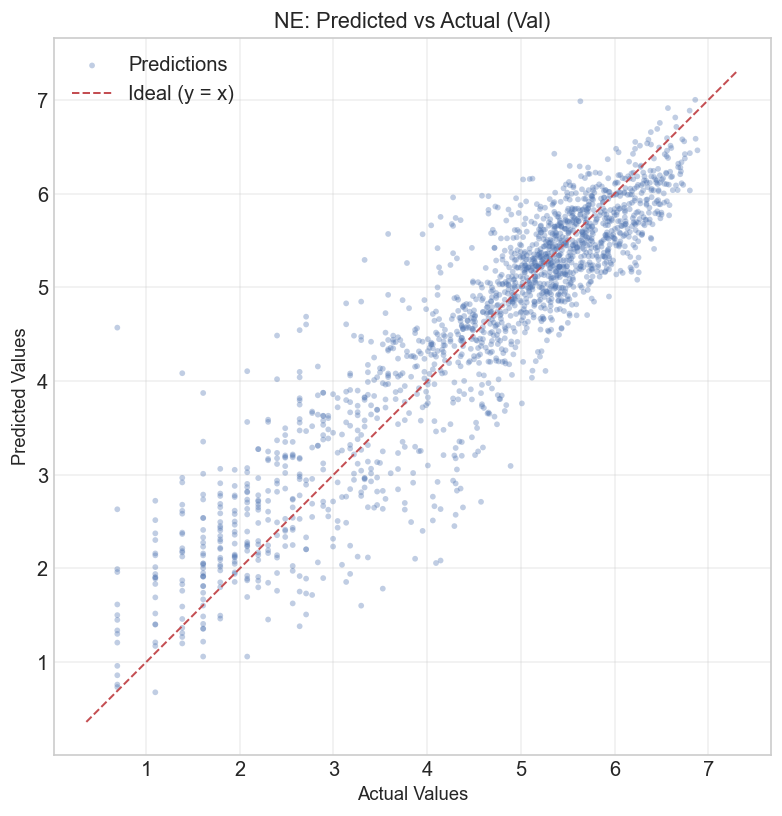

In [4]:
# Dự đoán trên tập Validation và Test
y_val_pred_ne = ne_model.predict(X_val)
y_test_pred_ne = ne_model.predict(X_test)

# In Metrics
metrics_ne_val = {
    "MSE": mse(y_val, y_val_pred_ne),
    "RMSE": rmse(y_val, y_val_pred_ne),
    "MAE": mae(y_val, y_val_pred_ne),
    "R2": r_squared(y_val, y_val_pred_ne)
}

print("Normal Equation - Validation Metrics:")
for k, v in metrics_ne_val.items():
    print(f"  {k}: {v:.4f}")

plot_predicted_vs_actual(y_val, y_val_pred_ne, title="NE: Predicted vs Actual (Val)")


## 3. Mini-batch Gradient Descent
Ở đây ta sử dụng Mini-batch GD với step decay learning rate.

In [5]:
# Khởi tạo và huấn luyện Mini-Batch GD LR
gd_model = MiniBatchGDLR(
    lr=0.01,
    n_epochs=200,
    batch_size=128,
    lr_schedule='step_decay',
    decay_rate=0.7,
    decay_steps=50,
    verbose=True
)
gd_model.fit(X_train, y_train)

print(f"\nMini-Batch GD fit time: {gd_model.fit_time:.4f}s")


  Epoch    0 | lr=0.010000 | MSE=1.742373
  Epoch   50 | lr=0.007000 | MSE=0.417131
  Epoch  100 | lr=0.004900 | MSE=0.387686
  Epoch  150 | lr=0.003430 | MSE=0.380117
  Epoch  199 | lr=0.003430 | MSE=0.376834

Mini-Batch GD fit time: 0.2814s


### Đánh giá Mini-batch GD

Mini-batch GD - Validation Metrics:
  MSE: 0.3421
  RMSE: 0.5849
  MAE: 0.4403
  R2: 0.8304


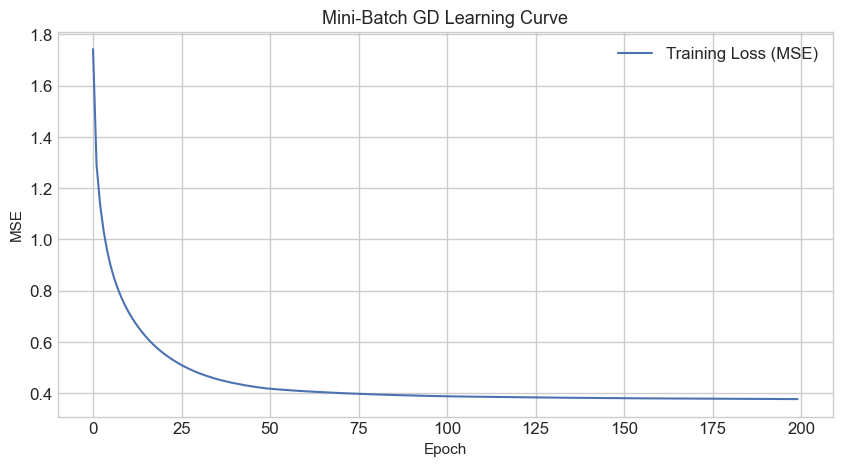

<Axes: title={'center': 'MB-GD: Predicted vs Actual (Val)'}, xlabel='Actual Values', ylabel='Predicted Values'>

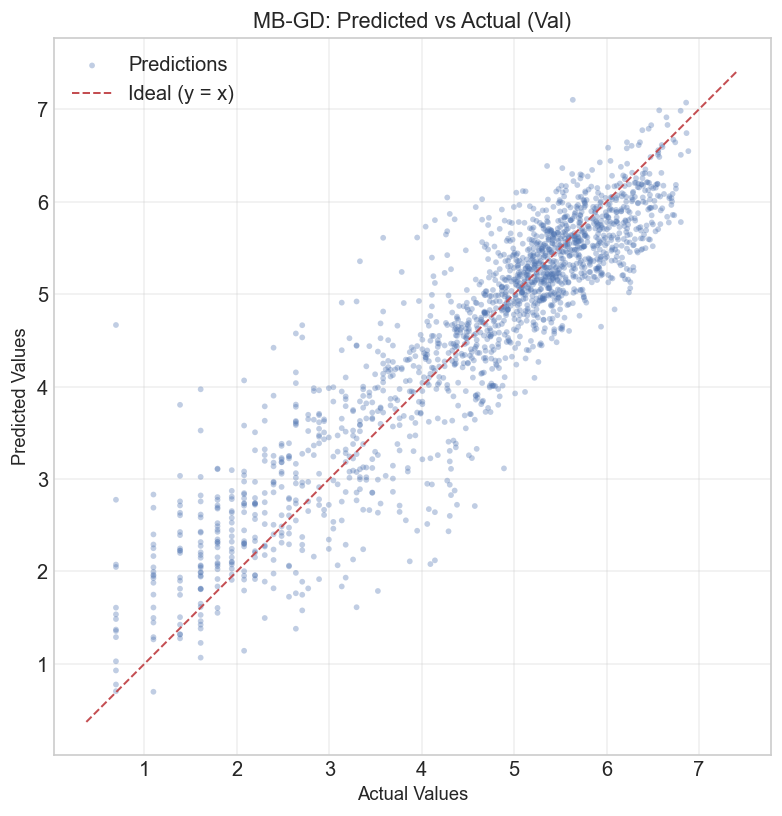

In [6]:
y_val_pred_gd = gd_model.predict(X_val)

metrics_gd_val = {
    "MSE": mse(y_val, y_val_pred_gd),
    "RMSE": rmse(y_val, y_val_pred_gd),
    "MAE": mae(y_val, y_val_pred_gd),
    "R2": r_squared(y_val, y_val_pred_gd)
}

print("Mini-batch GD - Validation Metrics:")
for k, v in metrics_gd_val.items():
    print(f"  {k}: {v:.4f}")

# Vẽ learning curve (Loss theo epochs)
plt.figure(figsize=(10, 5))
plt.plot(gd_model.loss_history, label='Training Loss (MSE)')
plt.title('Mini-Batch GD Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

plot_predicted_vs_actual(y_val, y_val_pred_gd, title="MB-GD: Predicted vs Actual (Val)")


## 4. Kiểm tra giả định Gauss-Markov
Sử dụng model Normal Equation để kiểm tra trên tập Test.

Check Gauss-Markov assumptions on Test set (NE model):

=== Gauss–Markov Diagnostics ===
  Residual mean : 0.004125  (should be ≈ 0)
  Residual std  : 0.591037

  Breusch–Pagan test:
    LM statistic : 1095.0072
    p-value      : 0.000000
    F statistic  : 32.1510
    F p-value    : 0.000000
    → Heteroscedasticity DETECTED (p < 0.05)
    → Consider using Weighted Least Squares (WLS)


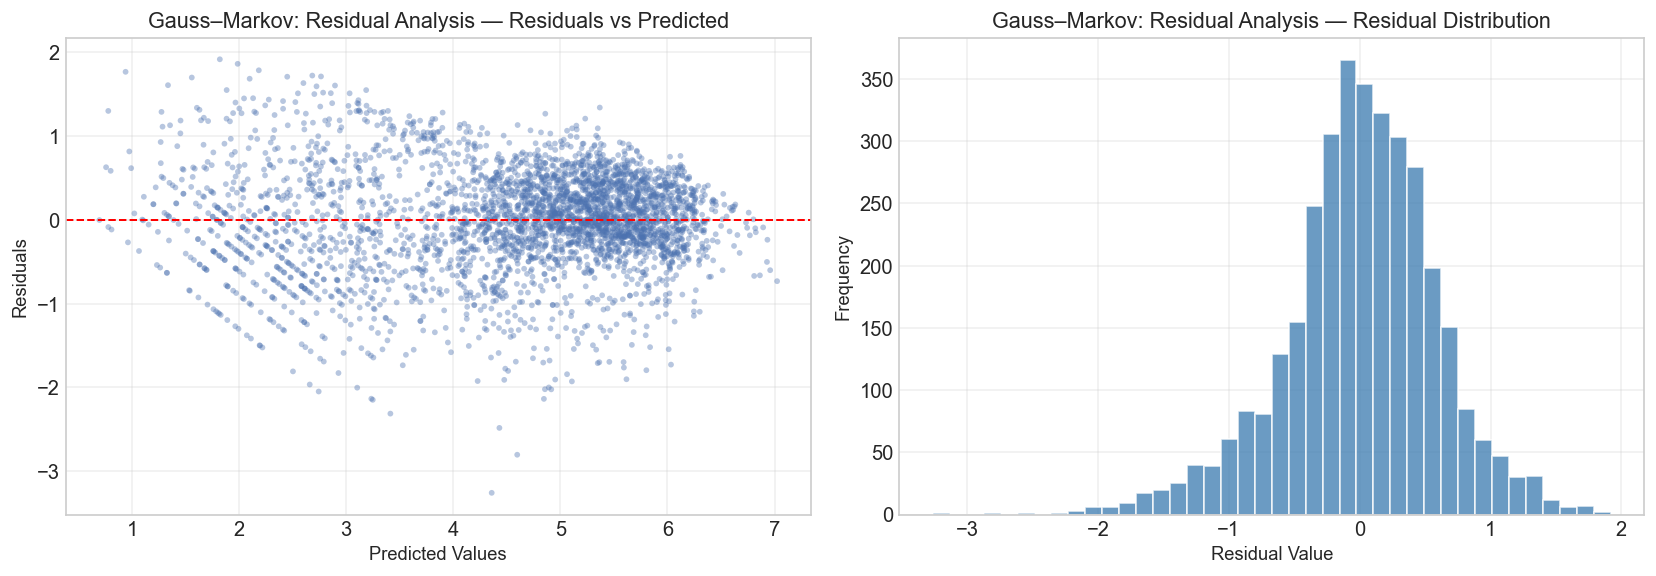

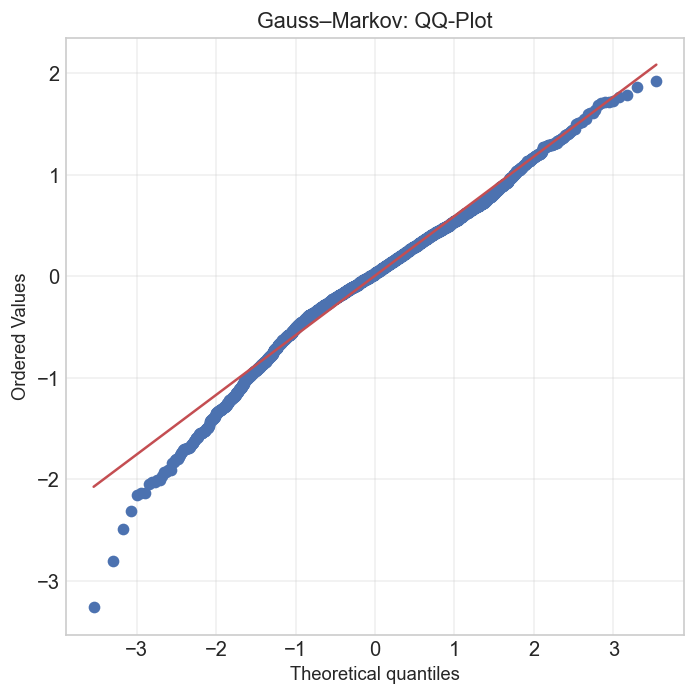

In [7]:
# Gauss-Markov diagnostics trên Test set
print("Check Gauss-Markov assumptions on Test set (NE model):")
y_test_pred_ne = ne_model.predict(X_test)

gm_results = gauss_markov_diagnostics(y_test, y_test_pred_ne, X_test, plot=True)


## 5. Weighted Least Squares (WLS)
Nếu kiểm định Breusch-Pagan báo cáo sự tồn tại của phương sai sai số thay đổi (heteroscedasticity), ta sẽ giải quyết bằng cách áp dụng WLS. Ta có thể ước lượng phương sai của mỗi mẫu bằng cách hồi quy bình phương residuals theo X hoặc theo y_pred.
Trong ví dụ này, ta tính weights tỷ lệ nghịch với bình phương residuals dự đoán (đơn giản hoá: $weight_i = \frac{1}{|y\_pred_i| + \epsilon}$).


Áp dụng WLS...

WLS - Test Metrics:
  MSE: 0.3515
  RMSE: 0.5929
  MAE: 0.4486
  R2: 0.8240

=== Gauss–Markov Diagnostics ===
  Residual mean : 0.005222  (should be ≈ 0)
  Residual std  : 0.592846

  Breusch–Pagan test:
    LM statistic : 1092.7016
    p-value      : 0.000000
    F statistic  : 32.0523
    F p-value    : 0.000000
    → Heteroscedasticity DETECTED (p < 0.05)
    → Consider using Weighted Least Squares (WLS)


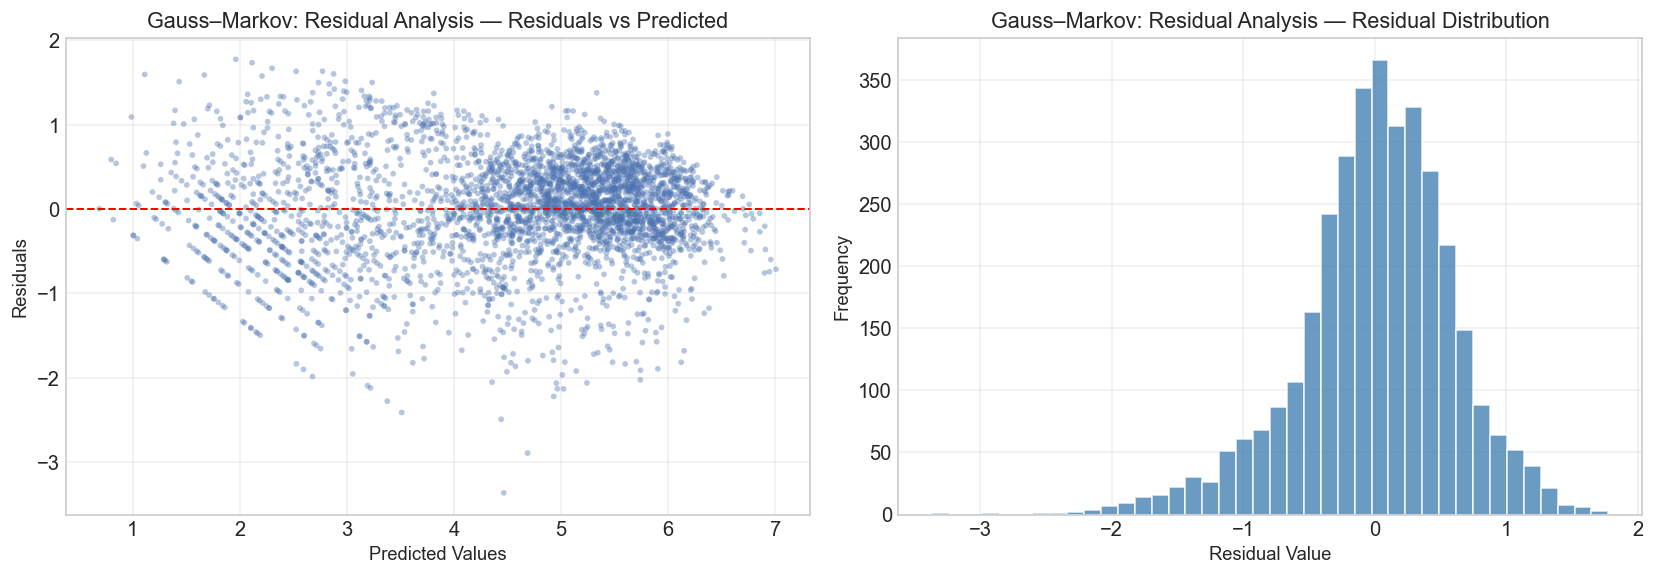

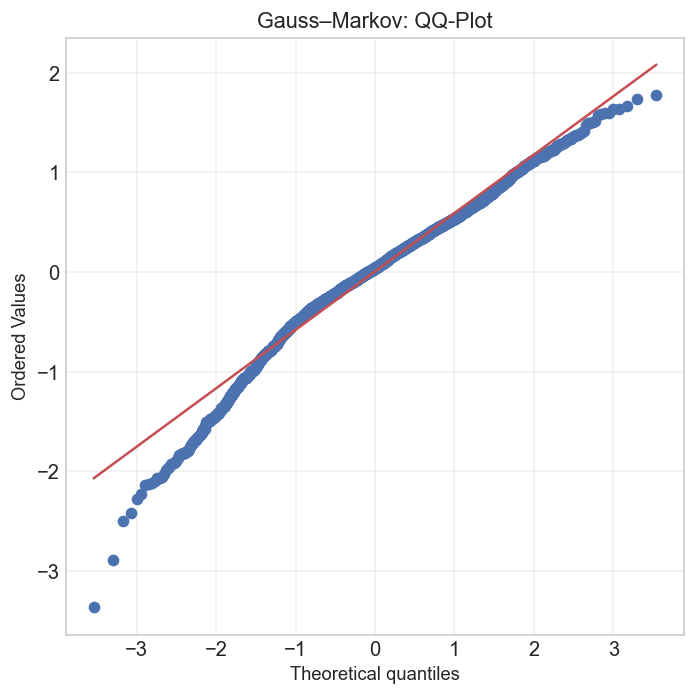

In [8]:
if gm_results['heteroscedastic']:
    print("\nÁp dụng WLS...")
    # Ước lượng weights trên tập train
    y_train_pred_ne = ne_model.predict(X_train)
    weights = 1.0 / (np.abs(y_train_pred_ne) + 1e-5)
    
    wls_model = WeightedLeastSquares()
    wls_model.fit(X_train, y_train, weights=weights)
    
    y_test_pred_wls = wls_model.predict(X_test)
    
    metrics_wls_test = {
        "MSE": mse(y_test, y_test_pred_wls),
        "RMSE": rmse(y_test, y_test_pred_wls),
        "MAE": mae(y_test, y_test_pred_wls),
        "R2": r_squared(y_test, y_test_pred_wls)
    }
    
    print("\nWLS - Test Metrics:")
    for k, v in metrics_wls_test.items():
        print(f"  {k}: {v:.4f}")
        
    # Check lại Gauss-Markov bằng dự đoán của WLS
    gm_results_wls = gauss_markov_diagnostics(y_test, y_test_pred_wls, X_test, plot=True)


## Lưu kết quả cho báo cáo
Tổng hợp metrics để so sánh chéo giữa các Phase.

In [9]:
import joblib

os.makedirs("../results", exist_ok=True)

# Test metrics for NE
y_test_pred_ne = ne_model.predict(X_test)
metrics_ne_test = {
    "MSE": mse(y_test, y_test_pred_ne),
    "RMSE": rmse(y_test, y_test_pred_ne),
    "MAE": mae(y_test, y_test_pred_ne),
    "R2": r_squared(y_test, y_test_pred_ne)
}

results = {
    "LinearRegression_NE": metrics_ne_test
}

if gm_results['heteroscedastic']:
    results["LinearRegression_WLS"] = metrics_wls_test

joblib.dump(results, "../results/metrics_03_linear_regression.joblib")
print("Đã lưu kết quả tại ../results/metrics_03_linear_regression.joblib")


Đã lưu kết quả tại ../results/metrics_03_linear_regression.joblib
